In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("amazon sale report.csv", low_memory=False)
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,SET389,SET389-KR-NP-S,Set,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,NaN,False,Easy Ship,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,JNE3781,JNE3781-KR-XXXL,kurta,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3371,JNE3371-KR-XL,kurta,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,True,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,J0341,J0341-DR-L,Western Dress,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,NaN,False,Easy Ship,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,JNE3671,JNE3671-TU-XXXL,Top,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,NaN,False,NaN,NaN


In [2]:
df.shape
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128975 entries, 0 to 128974
Data columns (total 24 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128975 non-null  int64  
 1   Order ID            128975 non-null  object 
 2   Date                128975 non-null  object 
 3   Status              128975 non-null  object 
 4   Fulfilment          128975 non-null  object 
 5   Sales Channel       128975 non-null  object 
 6   ship-service-level  128975 non-null  object 
 7   Style               128975 non-null  object 
 8   SKU                 128975 non-null  object 
 9   Category            128975 non-null  object 
 10  Size                128975 non-null  object 
 11  ASIN                128975 non-null  object 
 12  Courier Status      122103 non-null  object 
 13  Qty                 128975 non-null  int64  
 14  currency            121180 non-null  object 
 15  Amount              121180 non-nul

index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

In [3]:
# Drop unnecessary columns
df = df.drop(columns=['Unnamed: 22', 'promotion-ids'], errors='ignore')

# Fill missing values
df['Amount'] = df['Amount'].fillna(0)
df['currency'] = df['currency'].fillna('Unknown')
df['Courier Status'] = df['Courier Status'].fillna('Unknown')
df['fulfilled-by'] = df['fulfilled-by'].fillna('Unknown')

# Drop critical missing rows
df = df.dropna(subset=['ship-city', 'ship-state'])

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 128942 entries, 0 to 128974
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype         
---  ------              --------------   -----         
 0   index               128942 non-null  int64         
 1   Order ID            128942 non-null  object        
 2   Date                128942 non-null  datetime64[ns]
 3   Status              128942 non-null  object        
 4   Fulfilment          128942 non-null  object        
 5   Sales Channel       128942 non-null  object        
 6   ship-service-level  128942 non-null  object        
 7   Style               128942 non-null  object        
 8   SKU                 128942 non-null  object        
 9   Category            128942 non-null  object        
 10  Size                128942 non-null  object        
 11  ASIN                128942 non-null  object        
 12  Courier Status      128942 non-null  object        
 13  Qty                 128942 non-nul

C:\Users\k sravani\AppData\Local\Temp\ipykernel_15636\2188901164.py:14: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'], errors='coerce')


In [4]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day

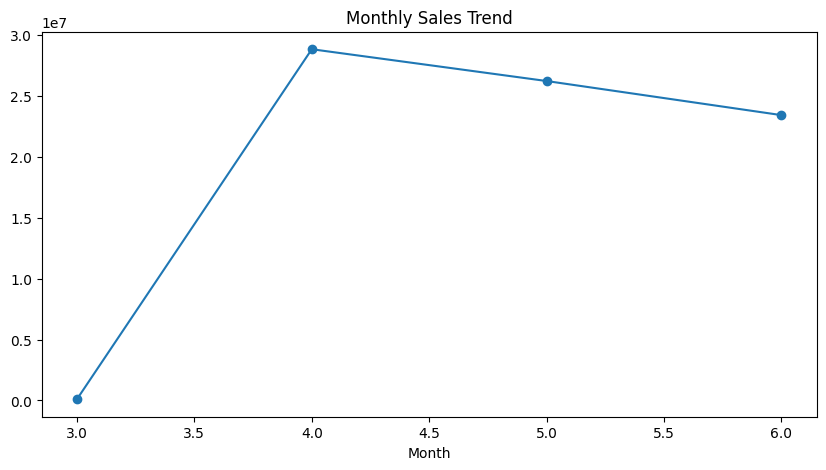

In [5]:
monthly_sales = df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='line', marker='o')
plt.title("Monthly Sales Trend")
plt.show()

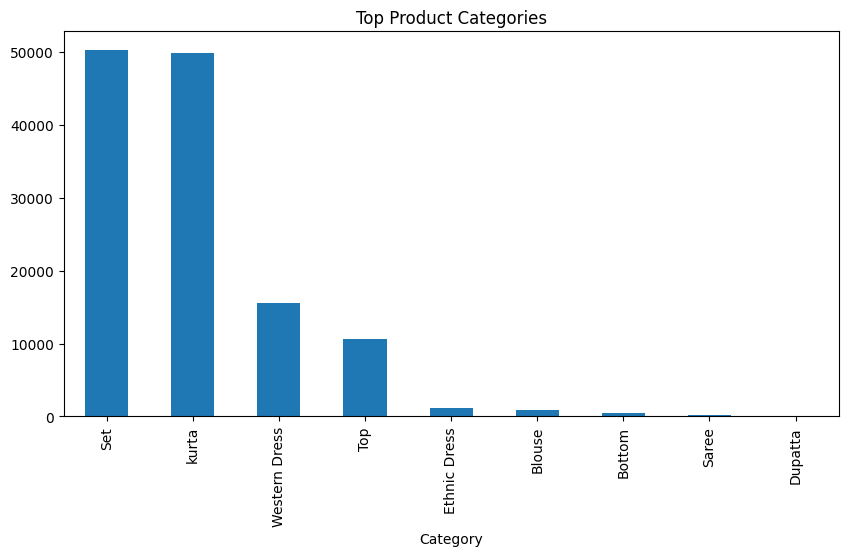

In [6]:
plt.figure(figsize=(10,5))
df['Category'].value_counts().plot(kind='bar')
plt.title("Top Product Categories")
plt.show()

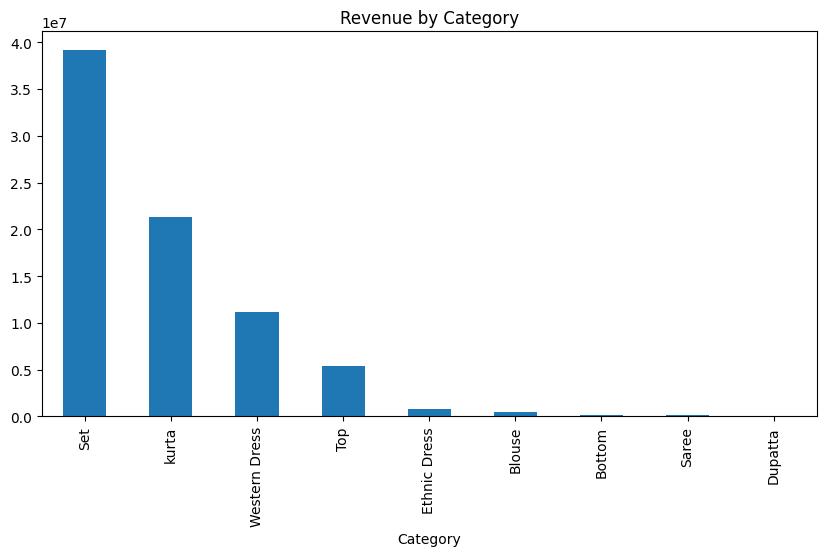

In [7]:
plt.figure(figsize=(10,5))
df.groupby('Category')['Amount'].sum().sort_values(ascending=False).plot(kind='bar')
plt.title("Revenue by Category")
plt.show()

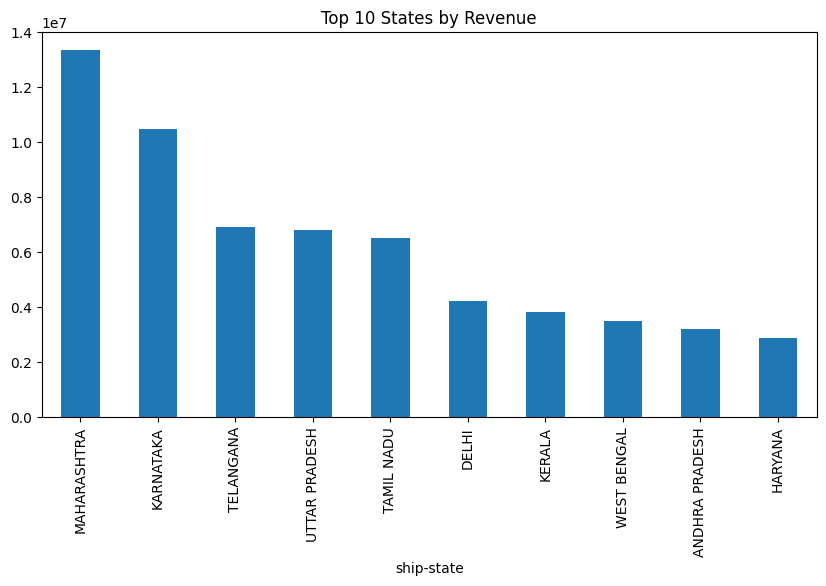

In [8]:
plt.figure(figsize=(10,5))
df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 States by Revenue")
plt.show()

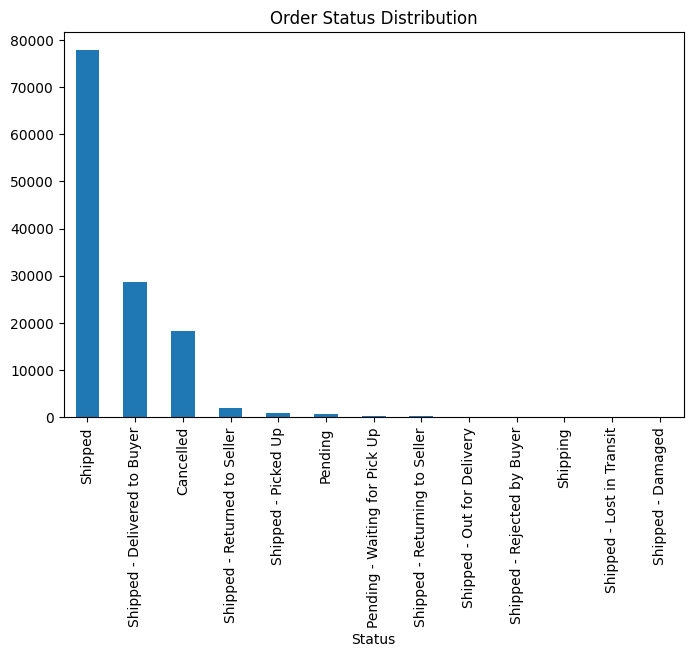

In [9]:
plt.figure(figsize=(8,5))
df['Status'].value_counts().plot(kind='bar')
plt.title("Order Status Distribution")
plt.show()

In [ ]:
1. Sales are highest in specific months indicating seasonal demand patterns.

2. Certain product categories dominate revenue generation.

3. Maharashtra and Karnataka are the top contributing states.

4. Most orders are successfully shipped, indicating efficient fulfillment.

5. Revenue is unevenly distributed across categories, showing key business focus areas.